In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install tldextract

In [3]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
phish_df = pd.read_csv("/content/drive/MyDrive/SKRIPSI/dataset/online-valid.csv")
phish_df

,phish_id,url,phish_detail_url,submission_time,verified,verification_time,online,target
0,9080757,https://id.pasting.pos-init.com/identifier?pag...,http://www.phishtank.com/phish_detail.php?phis...,2025-04-29T07:10:11+00:00,yes,2025-04-29T16:02:25+00:00,yes,Other
1,9080755,https://aust24.net/fixingdelay,http://www.phishtank.com/phish_detail.php?phis...,2025-04-29T06:58:11+00:00,yes,2025-04-29T15:51:44+00:00,yes,Australian Taxation Office
2,9080751,http://help--suite--blog.gitbook.io/en-us,http://www.phishtank.com/phish_detail.php?phis...,2025-04-29T06:29:55+00:00,yes,2025-04-29T15:41:48+00:00,yes,Other
3,9080752,https://help--suite--blog.gitbook.io/en-us,http://www.phishtank.com/phish_detail.php?phis...,2025-04-29T06:29:55+00:00,yes,2025-04-29T15:41:48+00:00,yes,Other
4,9080749,https://home-en-bridge-cdn.gitbook.io/us,http://www.phishtank.com/phish_detail.php?phis...,2025-04-29T06:25:01+00:00,yes,2025-04-29T15:41:48+00:00,yes,Other
...,...,...,...,...,...,...,...,...
62100,3573703,http://www.ezblox.site/free/jennifer111/helpdesk,http://www.phishtank.com/phish_detail.php?phis...,2015-11-03T14:41:38+00:00,yes,2016-03-15T18:51:08+00:00,yes,Other
62101,2042606,http://www.formbuddy.com/cgi-bin/formdisp.pl?u...,http://www.phishtank.com/phish_detail.php?phis...,2013-09-30T13:24:39+00:00,yes,2013-10-01T13:33:17+00:00,yes,Other
62102,1865971,http://www.formbuddy.com/cgi-bin/formdisp.pl?u...,http://www.phishtank.com/phish_detail.php?phis...,2013-05-28T15:59:31+00:00,yes,2013-05-28T22:13:12+00:00,yes,Other
62103,1460953,http://www.habbocreditosparati.blogspot.com/,http://www.phishtank.com/phish_detail.php?phis...,2012-06-14T15:19:26+00:00,yes,2012-06-14T15:29:11+00:00,yes,Sulake Corporation


In [5]:
benign_df = pd.read_csv("/content/drive/MyDrive/SKRIPSI/dataset/top-1m.csv", names=["url"]).sample(n=62105, random_state=42)
benign_df

,url
987232,pgbb.dyndns.org
79955,libyaninvestment.com
567131,athyrabunlord.tumblr.com
500892,harmony.ie
55400,big4umovies.net
...,...
776569,artshow.com
523015,shub.ir
318643,mattressman.co.uk
441632,beiangtech.com


In [6]:
phish_df["label"] = 1
benign_df["label"] = 0

In [7]:
df = pd.concat([phish_df[["url", "label"]], benign_df[["url", "label"]]], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [8]:
print(df.head())

                       url  label
0  https://l.ead.me/bfKtON      1
1           atthemoment.us      0
2           jayrambhia.com      0
3       http://inx.lv/9GkK      1
4           samsmarine.com      0


In [9]:
# tampilkan jumlah kolom dan baris pada data
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 124210
Number of columns: 2


In [10]:
import tldextract

# Ekstraksi domain
df['subdomain'] = df['url'].apply(lambda x: tldextract.extract(x).subdomain)
df['domain'] = df['url'].apply(lambda x: tldextract.extract(x).domain)
df['suffix'] = df['url'].apply(lambda x: tldextract.extract(x).suffix)
df

,url,label,subdomain,domain,suffix
0,https://l.ead.me/bfKtON,1,l,ead,me
1,atthemoment.us,0,,atthemoment,us
2,jayrambhia.com,0,,jayrambhia,com
3,http://inx.lv/9GkK,1,,inx,lv
4,samsmarine.com,0,,samsmarine,com
...,...,...,...,...,...
124205,redakcja.pl,0,,redakcja,pl
124206,gphotels.jp,0,,gphotels,jp
124207,https://com-ghbv.win/,1,,com-ghbv,win
124208,https://some-eiglayer.webflow.io/,1,some-eiglayer,webflow,io


In [14]:
from transformers import DistilBertTokenizer

# Tokenisasi
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
tokenizer.save_pretrained("/content/drive/MyDrive/SKRIPSI/MODEL")

def tokenize(texts, max_len=38):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=max_len,
        return_tensors="tf"
    )

combined = df[['subdomain', 'domain', 'suffix']].astype(str).agg(' '.join, axis=1)

# Lalu tokenisasi
tokens = tokenize(combined)
tokens

{'input_ids': <tf.Tensor: shape=(124210, 38), dtype=int32, numpy=
array([[  101,  1048, 19413, ...,     0,     0,     0],
       [  101,  2012, 10760, ...,     0,     0,     0],
       [  101,  6108,  6444, ...,     0,     0,     0],
       ...,
       [  101,  4012,  1011, ...,     0,     0,     0],
       [  101,  2070,  1011, ...,     0,     0,     0],
       [  101,  8135,  5794, ...,     0,     0,     0]], dtype=int32)>, 'attention_mask': <tf.Tensor: shape=(124210, 38), dtype=int32, numpy=
array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]], dtype=int32)>}

In [15]:
!pip install keras_tuner

In [16]:
import keras_tuner as kt
import tensorflow as tf
from tensorflow.keras.regularizers import l2
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Lambda, Dropout, LayerNormalization
from tensorflow.keras.optimizers import AdamW
from transformers import TFDistilBertModel  # Import TFDistilBertModel

In [17]:
labels = df['label'].values

# Pisahkan dataset awal menjadi X_train dan X_temp
input_ids = tokens['input_ids'].numpy()
attention_mask = tokens['attention_mask'].numpy()

# Split awal dari seluruh data ke X_train dan sisanya (X_temp) untuk val/test
X_train_ids, X_temp_ids, y_train, y_temp = train_test_split(input_ids, labels, test_size=0.2, random_state=42)
X_train_mask, X_temp_mask = train_test_split(attention_mask, test_size=0.2, random_state=42)

X_train = {
    'input_ids': X_train_ids,
    'attention_mask': X_train_mask
}
X_temp = {
    'input_ids': X_temp_ids,
    'attention_mask': X_temp_mask
}


In [18]:
X_val_ids, X_test_ids, y_val, y_test = train_test_split(X_temp['input_ids'], y_temp, test_size=0.5, random_state=42)
X_val_mask, X_test_mask = train_test_split(X_temp['attention_mask'], test_size=0.5, random_state=42)
X_val = {'input_ids': X_val_ids, 'attention_mask': X_val_mask}
X_test = {'input_ids': X_test_ids, 'attention_mask': X_test_mask}

In [19]:
print(type(X_train))
print(X_train.keys())

<class 'dict'>
dict_keys(['input_ids', 'attention_mask'])


In [20]:
from transformers import TFDistilBertModel

# Load DistilBERT model
bert_model = TFDistilBertModel.from_pretrained('distilbert-base-uncased')


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [21]:
# Initialize tuner
# Ensure the path exists in Kaggle's writable directory structure
best_model_dir = '/content/drive/MyDrive/SKRIPSI/MODEL'

# Make directory if not exists
import os
os.makedirs(best_model_dir, exist_ok=True)

In [22]:
def model_builder(hp):
    input_ids = Input(shape=(38,), dtype=tf.int32, name='input_ids')
    attention_mask = Input(shape=(38,), dtype=tf.int32, name='attention_mask')

    def call_bert(inputs):
        ids, mask = inputs
        return bert_model([ids, mask])[0][:, 0, :]  # Ambil token [CLS]

    bert_output = Lambda(call_bert, output_shape=(768,))([input_ids, attention_mask])
    x = LayerNormalization()(bert_output)

    # Hyperparameter tuning
    hidden_units = hp.Int('hidden_units', min_value=32, max_value=128, step=32)
    dropout_rate = hp.Float('dropout_rate', min_value=0.3, max_value=0.6, step=0.1)
    l2_strength = hp.Choice('l2_strength', values=[0.001, 0.005, 0.01])

    x = Dense(hidden_units, activation='relu', kernel_regularizer=l2(l2_strength))(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=[input_ids, attention_mask], outputs=output)

    # Inisialisasi AdamW
    # Inisialisasi AdamW
    optimizer = AdamW(
        learning_rate=2e-5,
        weight_decay=0.01
    )

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [23]:
# Initialize tuner
#Hyper parameter optimization nya RAndom Search
tuner = kt.RandomSearch(
    model_builder,
    objective='val_accuracy',
    max_trials=1,
    directory='keras_tuner_logs',
    project_name='phishing_detection'
)

In [24]:
# Membuat tf.data.Dataset dari hasil tokenisasi
train_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': X_train['input_ids'],
        'attention_mask': X_train['attention_mask']
    },
    y_train
)).shuffle(1000).batch(8)

val_dataset = tf.data.Dataset.from_tensor_slices((
    {
        'input_ids': X_val['input_ids'],
        'attention_mask': X_val['attention_mask']
    },
    y_val
)).batch(8)

# Perform tuning
tuner.search(train_dataset, validation_data=val_dataset, epochs=100) #bikin epochs 100

# Ambil model terbaik dan hyperparameters-nya
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best hyperparameters found:")
print(f" - hidden_units: {best_hps.get('hidden_units')}")
print(f" - dropout_rate: {best_hps.get('dropout_rate')}")
print(f" - l2_strength: {best_hps.get('l2_strength')}")

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Save the best model
best_model.save(best_model_dir + 'best_model.keras')

Trial 1 Complete [01h 24m 58s]
val_accuracy: 0.965542197227478

Best val_accuracy So Far: 0.965542197227478
Total elapsed time: 01h 24m 58s
Best hyperparameters found:
 - hidden_units: 128
 - dropout_rate: 0.3
 - l2_strength: 0.001


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [25]:
from sklearn.metrics import roc_curve, auc

# Siapkan test dataset
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(8)

# Prediksi probabilitas
y_pred_probs = best_model.predict(test_dataset)

1553/1553 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step


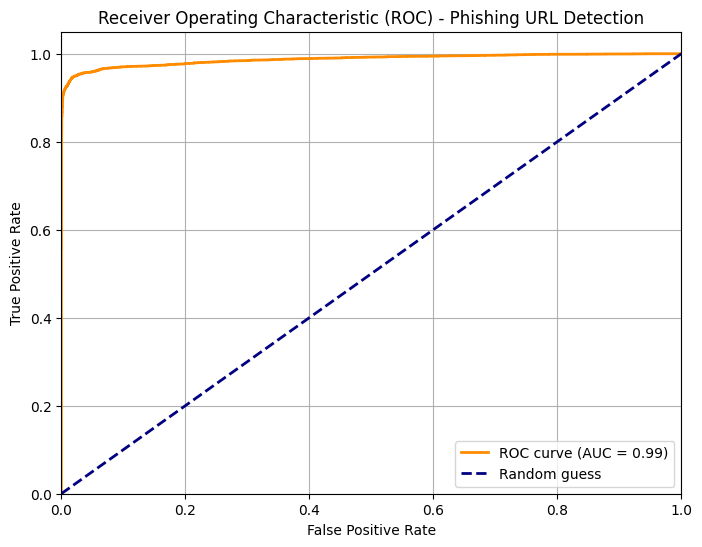

In [26]:
# ROC membutuhkan label asli dan prediksi probabilitas
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Phishing URL Detection')
plt.legend(loc="lower right")
plt.grid()
plt.show()


In [27]:
# Evaluasi best_model di dataset test
test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(8)
loss, accuracy = best_model.evaluate(test_dataset)

print(f"Best Model Test Accuracy: {accuracy:.4f}")


1553/1553 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9605 - loss: 0.1424
Best Model Test Accuracy: 0.9640


In [28]:
from sklearn.metrics import confusion_matrix, classification_report

1553/1553 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


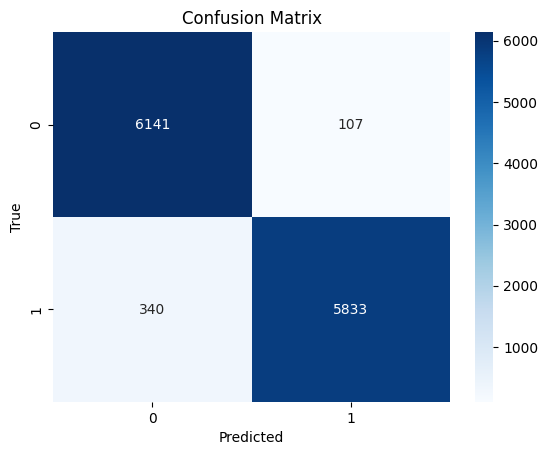

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      6248
           1       0.98      0.94      0.96      6173

    accuracy                           0.96     12421
   macro avg       0.96      0.96      0.96     12421
weighted avg       0.96      0.96      0.96     12421



In [29]:
# Prediksi
y_pred = (best_model.predict(test_dataset) > 0.5).astype(int)
y_true = np.concatenate([y for x, y in test_dataset], axis=0)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred))

Evaluating best_model.keras on the test set:
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9605 - loss: 0.1424
Test Loss: 0.1341
Test Accuracy: 0.9640
1553/1553 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


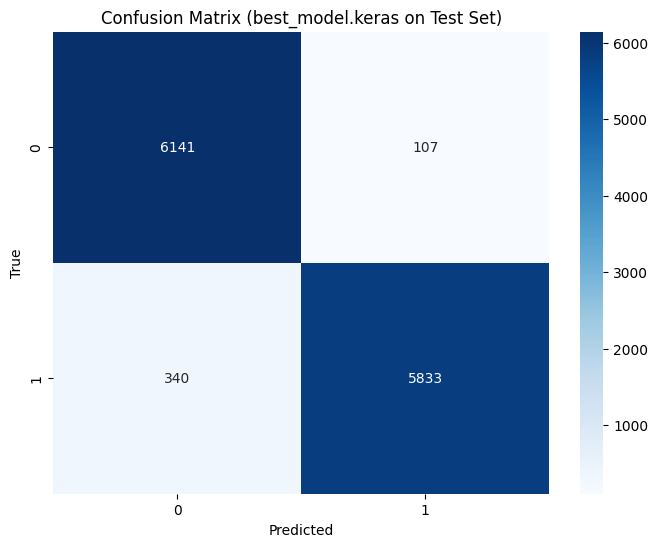

Classification Report (best_model.keras on Test Set):
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      6248
           1       0.98      0.94      0.96      6173

    accuracy                           0.96     12421
   macro avg       0.96      0.96      0.96     12421
weighted avg       0.96      0.96      0.96     12421



In [30]:
# prompt: cek akurasi model best_model.keras

# Cek akurasi model best_model.keras pada test set
print("Evaluating best_model.keras on the test set:")
loss, accuracy = best_model.evaluate(test_dataset)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Prediksi pada test set
y_pred = (best_model.predict(test_dataset) > 0.5).astype(int)
y_true = np.concatenate([y for x, y in test_dataset], axis=0) # Ambil label sebenarnya dari test_dataset

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (best_model.keras on Test Set)')
plt.show()

# Classification Report
print("Classification Report (best_model.keras on Test Set):")
print(classification_report(y_true, y_pred))